1. LOAD THE DATA
</br>read the JSON files and turn into input to the system

get access to google drives content to get the txt files.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


import libraries

In [ ]:
import ast
import numpy as np
import matplotlib.pyplot as plt

loading data

In [ ]:
def load_json_list(path: str):
    data = []
    with open(path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            obj = ast.literal_eval(line)
            data.append(obj)
    return data

2. Setting system status: </br>
state vector is of 6 elements: [x,y,z,pitch,roll,yaw]

In [ ]:
def init_kalman(dt, q_process, r_measure):
    # State: [x, y, z, roll, pitch, yaw]
    x0 = np.zeros((6, 1))
    P0 = np.eye(6) * 0.1

    F = np.eye(6)

    # B maps World velocities [vx, vy, vz] to World positions [x, y, z]
    B = np.zeros((6, 3))
    B[0, 0] = dt
    B[1, 1] = dt
    B[2, 2] = dt

    H = np.eye(6)
    Q = np.eye(6) * q_process
    R = np.eye(6) * r_measure

    return x0, P0, F, B, H, Q, R

Kalman filter code

In [ ]:
def predict(x, P, F, B, u, Q):

    x_pred = F @ x + B @ u
    P_pred = F @ P @ F.T + Q

    return x_pred, P_pred


def update(x_pred, P_pred, H, R, z):

    I = np.eye(x_pred.shape[0], dtype=float)

    y = z - (H @ x_pred)
    S = H @ P_pred @ H.T + R
    K = P_pred @ H.T @ np.linalg.inv(S)

    x_upd = x_pred + K @ y
    P_upd = (I - K @ H) @ P_pred

    return x_upd, P_upd, K


3. the relationship between the axis:</br>
- World system: </br>X: lateral right positive אופקי
 </br>Y:vertical, down positive אנכי
 </br>Z:Forward Positive</br>
- IMU system: </br>
 X:Backward Positive</br>
Y:Lateral Left</br>
 Z:Vertical Top </br>


In [ ]:
#matrix to map imu to world

R_imu_to_world = np.array([
    [ 0, -1,  0],   # World X = -IMU Y
    [ 0,  0, -1],   # World Y = -IMU Z
    [-1,  0,  0]    # World Z = -IMU X
])


def run_filter(inertial_data, meas_data, dt, q_process, r_measure):
    n = min(len(inertial_data), len(meas_data))

    # FIX: Call with exactly 3 arguments
    x, P, F, B, H, Q, R = init_kalman(dt, q_process, r_measure)

    xs_pure_inertial = []
    xs_upd = []
    K_hist = []

    x_pure = np.zeros((6, 1))
    meas_pos = np.zeros((3, 1))

    for k in range(n):
        # --- 1. PREDICTION (IMU) ---
        v_imu = np.array([
            [float(inertial_data[k].get("vgx", 0))],
            [float(inertial_data[k].get("vgy", 0))],
            [float(inertial_data[k].get("vgz", 0))]
        ])

        # Transform IMU -> World
        v_world = R_imu_to_world @ v_imu

        # Pure Path
        x_pure[0:3] += v_world * dt
        x_pure[3:6] = np.array([[float(inertial_data[k].get("roll", 0))],
                                [float(inertial_data[k].get("pitch", 0))],
                                [float(inertial_data[k].get("yaw", 0))]])
        xs_pure_inertial.append(x_pure.flatten())

        # Kalman Predict
        x_p, P_p = predict(x, P, F, B, v_world, Q)

        # --- 2. MEASUREMENT ---
        vm_imu = np.array([
            [float(meas_data[k].get("vgx", 0))],
            [float(meas_data[k].get("vgy", 0))],
            [float(meas_data[k].get("vgz", 0))]
        ])
        vm_world = R_imu_to_world @ vm_imu

        meas_pos += vm_world * dt

        z = np.zeros((6, 1))
        z[0:3] = meas_pos
        z[3] = float(meas_data[k].get("roll", 0))
        z[4] = float(meas_data[k].get("pitch", 0))
        z[5] = float(meas_data[k].get("yaw", 0))

        # --- 3. UPDATE ---
        x, P, K = update(x_p, P_p, H, R, z)

        xs_upd.append(x.flatten())
        K_hist.append(K[0, 0])

    return np.array(xs_pure_inertial), np.array(xs_upd), np.array(K_hist)

4. prediction using a movement model:</br> the prediction part of kalman filter while using the input on the speed and acceleration.</br> note: we can assume that the noise of the prediction is so small ~0.00001

5. update using the measurmant:</br> combine the measurments collected to update the current state.</br> assume: the noise of the measurement differs. we should run with the noise matrix: R_k = 0.05,5,50,500


In [ ]:
def main():
    # Paths
    inertial_path = '/content/drive/MyDrive/Navigation/inertial_data.txt'
    meas_path = '/content/drive/MyDrive/Navigation/measurement_data.txt'

    # Load data
    inertial_data = load_json_list(inertial_path)
    meas_data = load_json_list(meas_path)

    print(f"Loaded {len(inertial_data)} model rows and {len(meas_data)} measurement rows.")

    #given variables
    dt = 0.1
    q_process = 1e-5
    R_values = [0.05, 5, 50, 500]

    for r_measure in R_values:
        print(f"Running filter with R = {r_measure}...")

        # Now returns 3 values properly
        xs_pred, xs_upd, K_hist = run_filter(
            inertial_data, meas_data, dt, q_process, r_measure
        )

        # Plotting Path (X vs Z)
        plt.figure(figsize=(8, 5))
        plt.plot(xs_pred[:, 0], xs_pred[:, 2], 'b--', alpha=0.6, label='Prediction')
        plt.plot(xs_upd[:, 0], xs_upd[:, 2], 'r-', label='Update')
        plt.xlabel("X Position")
        plt.ylabel("Z Position")
        plt.title(f"Drone Path (R = {r_measure})")
        plt.legend()
        plt.grid(True, linestyle=":")
        plt.show()

        # Plotting Kalman Gain
        plt.figure(figsize=(8, 3))
        plt.plot(K_hist, color='purple')
        plt.xlabel("Time")
        plt.ylabel("Gain")
        plt.title(f"Kalman Gain (R = {r_measure})")
        plt.grid(True, linestyle=":")
        plt.show()

6. show results:</br> creat a PDF that shows the path before and after the update. </br> in blue the prediction and in red the update.</br> plot a graph the value of the 'Gain' of Kalman filter in every stage.</br> do a number of runs with the diffrent values of noise and check the affect of them in the results.

Loaded 797 model rows and 797 measurement rows.
Running filter with R = 0.05...


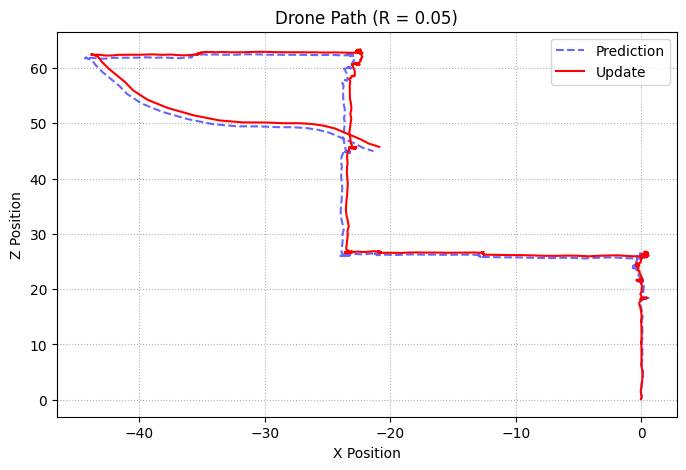

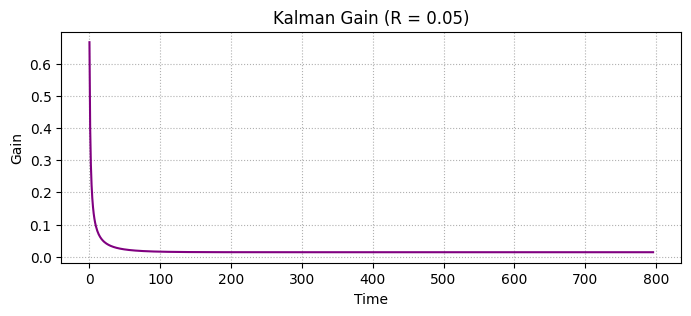

Running filter with R = 5...


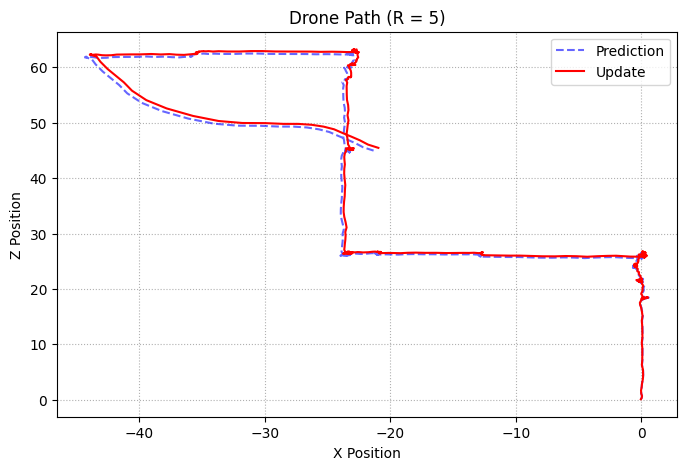

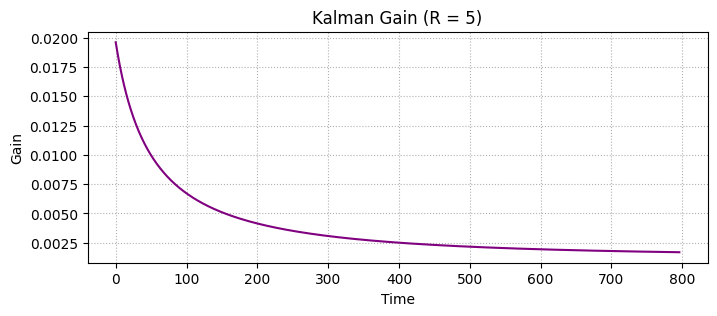

Running filter with R = 50...


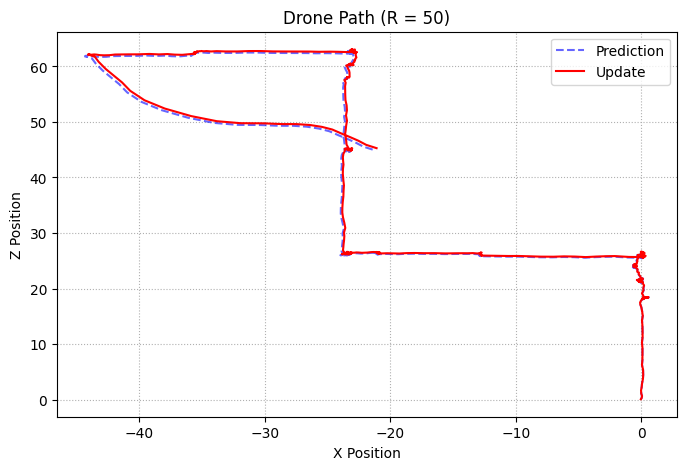

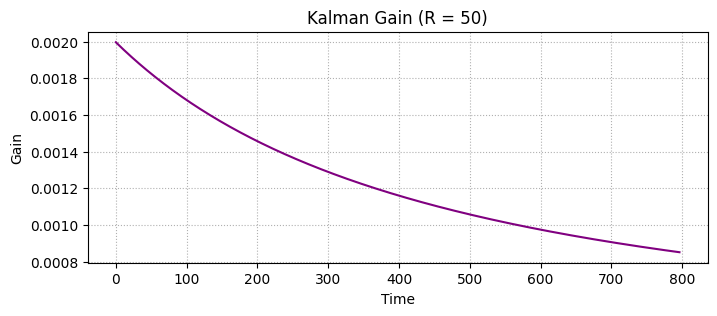

Running filter with R = 500...


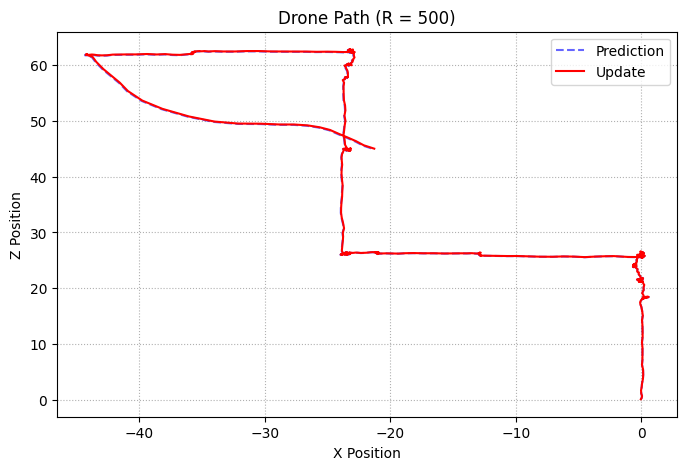

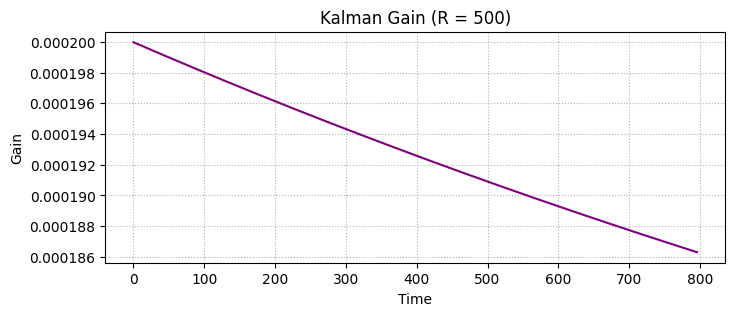

In [ ]:
if __name__ == "__main__":
    main()